# Домашнее задание 2: DPO и PPO

В этой домашке поближе познакомимся с двумя крайне популярными методами алаймента языковых моделей. В первой части вам предоставится возможность самостоятельно заимплементить DPO c нуля. Во второй части мы уже будем использовать библиотеку TRL и обучим PPO.

Обученные модели можно и нужно выложить на [🤗 HuggingFace](https://huggingface.co/). Зарегистрируйтесь там, подпишитесь на [deep vk](https://huggingface.co/deepvk) и создайте себе API токен.

Следуйте ячейкам тетрадки и заполняйте пропущенные ячейки. В конце тетрадки вы найдете задачи со звездочкой, чтобы получить максимальный балл!

## Импорты и вспомогательные функции

In [ ]:
# Установим необходимые дополнительные библиотеки

%pip install --quiet datasets trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 335.7/335.7 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# Необходимые импорты (для обоих частей)
import inspect
import random
from functools import partial

import numpy as np
import torch
import torch.nn.functional as F
import wandb
from datasets import load_dataset
from huggingface_hub import HfApi, interpreter_login
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import (
    AutoModelForCausalLM,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    PreTrainedTokenizerBase,
)
from trl import PPOConfig, PPOTrainer, RewardConfig, RewardTrainer

In [ ]:
interpreter_login()


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|



/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Enter your token (input will not be visible): ··········
Add token as git credential? (Y/n) y


In [ ]:
# Подготовим репозиторий для будущей модели и токенизатора
username = HfApi().whoami()["name"]
REPO_NAME = f"{username}/llm-course-hw2"  # Или как вам хочется

print(f"Homework repository: '{REPO_NAME}'")

Homework repository: 'Aurelianous/llm-course-hw2'


In [ ]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)


# Этой функцией будут помечены все места, которые необходимо дозаполнить
# Это могут быть как целые функции, так и отдельные части внутри них
# Всегда можно воспользоваться интроспекцией и найти места использования этой функции :)
def todo():
    stack = inspect.stack()
    caller_frame = stack[1]
    function_name = caller_frame.function
    line_number = caller_frame.lineno
    raise NotImplementedError(f"TODO at {function_name}, line {line_number}")


def disable_dropout_in_model(model):
    for module in model.modules():
        if isinstance(module, torch.nn.Dropout):
            module.p = 0

# Часть 1: DPO

Крайне простой метод, который в свое время произвел фурор, т.к. выгодно выделялся на фоне PPO. В отличие от PPO, требующего отдельно обучать Reward Model, Value Model и больших усилий в имплементации, DPO не требует явной ревард модели, а только датасета с человеческими преференсами вида: промпт, выбранный человеком ответ, отвергнутный человеком ответ. Простота также видна из лосса, по сути это весь метод:
$$
L_\text{DPO}(\pi_{\theta}; \pi_\text{ref}) = -E_{(x, y_w, y_l)\sim D}\left[\log \sigma \left(
\beta \log \frac{\pi_{\theta}(y_w\mid x)}{\pi_\text{ref}(y_w\mid x)} \thinspace
{- \beta \log \frac{\pi_{\theta}(y_l\mid x)}{\pi_\text{ref}(y_l\mid x)}}\right)\right]
$$

где:

- $\pi_{\theta}$ LLM которую мы хотим заалайнить
- $\pi_\text{ref}$ референсная модель для регуляризации, как правило просто начальный чекпоинт
- $D$ датасет с преференсами
- $x$ промпт из датасета $D$
- $y_w$ ответ на промпт $x$ выбранный человеком (или тем кто размечал преференсы, это может быть и большая LLM)
- $y_l$ ответ на промпт $x$ отвергнутый человеком (или тем кто размечал преференсы, это может быть и большая LLM)
- $\beta$ гиперепараметр отвечающий за то, как далеко мы можем отходить от референсной модели

Во время имплементации советум внимательно прочитать оригинальную статью: [Direct Preference Optimization: Your Language Model is Secretly a Reward Model](https://arxiv.org/abs/2305.18290).

Для файнтюна мы будем использовать модель [HuggingFaceTB/SmolLM-135M-Instruct](https://huggingface.co/HuggingFaceTB/SmolLM-135M-Instruct), т.к. она маленького размера (поместится на Colab), но при этом умеет достаточно, чтобы увидеть изменения от алаймента. Более того, данная модель даже прошла стадию SFT, а поэтому в отличие от базовой модели (без Instruct) понимает формат чата (chat-template в transformers, дальше разберем) и имеет 'осознание' себя языковым ассистентом.

P.S. Если у вас есть доступ к вычислительным ресурсам типо A100 и больше, вы можете попробовать зафайнтюнить модель большего размера из этой же [линейки](https://huggingface.co/blog/smollm). Будьте внимательны, смотрите, чтобы она была с добавкой Instruct.

In [ ]:
MODEL_ID = "HuggingFaceTB/SmolLM-135M-Instruct"
DATASET_ID = "HumanLLMs/Human-Like-DPO-Dataset"

## Подготовка данных [2 балла]

Для начала нужно подготовить данные. В качестве датасета преференсов мы будем использовать [HumanLLMs/Human-Like-DPO-Dataset](https://huggingface.co/datasets/HumanLLMs/Human-Like-DPO-Dataset), который значительно повышает эмоциональность модели, количество используемых эмодзи и в целом снижает строгость следования шаблону "As a conversational AI, I ...".

Чтобы подготовить датасет нужно несколько простых этапов:
1. Привест данные к формату chat-template
2. После применить этот chat-template с помощью 'tokenizer.apply_chat_template'
3. Токенизировать получившиеся данные, попутно обрезав промпт и ответы до нужной длины, если надо.

Внимательно прочитайте [документацию по chat-templates](https://huggingface.co/docs/transformers/chat_templating). Для удобства данные приводят в начале в более верхне-уровневый формат такого вида:
```python
messages = [
    {"role": "system", "content": "You are a helpful assistant focused on technical topics."},
    {"role": "user", "content": "Can you explain what a chat template is?"},
    {"role": "assistant", "content": "A chat template structures conversations between users and AI models..."}
]
```
То есть модели можно задать разные роли, такие как например системный промпт, и в целом структурировать диалог между ассистентом и человеком. Обычно обучение этому происходит на этапе SFT. Данная репрезентация абстрагирует детали (конкретные токены) как этот формат используют разные модели. Чтобы перевести его в неспоредственно текстовый инпут в формате специфичном конкретной модели используется `tokenizer.apply_chat_template`.

In [ ]:
# понадобится для подготовки данных
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

tokenizer_config.json:   0%|          | 0.00/3.59k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.10M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/565 [00:00<?, ?B/s]

In [ ]:
dataset = load_dataset(DATASET_ID, split="train")
dataset[0]

README.md:   0%|          | 0.00/1.69k [00:00<?, ?B/s]

data.json:   0%|          | 0.00/28.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10884 [00:00<?, ? examples/s]

{'prompt': 'Oh, I just saw the best meme - have you seen it?',
 'chosen': "😂 Ah, no I haven't! I'm dying to know, what's the meme about? Is it a funny cat or a ridiculous situation? Spill the beans! 🤣",
 'rejected': "I'm an artificial intelligence language model, I don't have personal experiences or opinions. However, I can provide you with information on highly-rated and critically acclaimed films, as well as recommendations based on specific genres or themes. Would you like me to suggest some notable movies or discuss a particular genre of interest?"}

Приведите датасет к формату чата, где у промпта роль user, а у ответов assistant, а потом примените чат темплейт:

In [ ]:
def apply_chat_template(example: dict[str, str], tokenizer: PreTrainedTokenizerBase) -> dict[str, str]:
    """
    Transforms a dataset example into a formatted chat template using the provided tokenizer.

    Args:
        example (Dict[str, str]): A dictionary containing the following keys:
            - "prompt": The initial user prompt.
            - "chosen": The assistant's chosen response.
            - "rejected": The assistant's rejected response.
        tokenizer (PreTrainedTokenizerBase): An object that provides the `apply_chat_template` method
            for formatting the conversation.

    Returns:
        Dict[str, str]: A dictionary with the following keys:
            - "prompt": The formatted prompt string including the generation prompt.
            - "chosen": The formatted assistant's chosen response (with the prompt prefix removed).
            - "rejected": The formatted assistant's rejected response (with the prompt prefix removed).
    """
    # ========== TODO ==========
    #      Ваш код здесь       =
    # ==========================
    messages = [{"role": "user", "content": example["prompt"]}]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    full_chosen = tokenizer.apply_chat_template(messages + [{"role": "assistant", "content": example["chosen"]}], tokenize=False)
    full_rejected = tokenizer.apply_chat_template(messages + [{"role": "assistant", "content": example["rejected"]}], tokenize=False)
    return {"prompt": prompt, "chosen": full_chosen[len(prompt):], "rejected": full_rejected[len(prompt):]}


In [ ]:
dataset = dataset.map(apply_chat_template, fn_kwargs={"tokenizer": tokenizer})
dataset[0]

Map:   0%|          | 0/10884 [00:00<?, ? examples/s]

{'prompt': '<|im_start|>user\nOh, I just saw the best meme - have you seen it?<|im_end|>\n<|im_start|>assistant\n',
 'chosen': "😂 Ah, no I haven't! I'm dying to know, what's the meme about? Is it a funny cat or a ridiculous situation? Spill the beans! 🤣<|im_end|>\n",
 'rejected': "I'm an artificial intelligence language model, I don't have personal experiences or opinions. However, I can provide you with information on highly-rated and critically acclaimed films, as well as recommendations based on specific genres or themes. Would you like me to suggest some notable movies or discuss a particular genre of interest?<|im_end|>\n"}

После этих двух этапов данные должны выглядеть так (**обратите внимание на положение <|im_start|>assistant\n**, это важно!):
```
{
    'prompt': "<|im_start|>user\nOh, I just saw the best meme - have you seen it <|im_end|>\n<|im_start|>assistant\n",
    'chosen': "😂 Ah, no I haven't! I'm dying to know, what's the meme about? Is it a funny cat or a ridiculous situation? Spill the beans! 🤣<|im_end|>\n",
    'rejected': "I'm an artificial intelligence language model, I don't have personal experiences or opinions. However, I can provide you with information on highly-rated and critically acclaimed films, as well as recommendations based on specific genres or themes. Would you like me to suggest some notable movies or discuss a particular genre of interest?<|im_end|>\n"
}
```

Токенизируйте датасет с помощью токенизатора, обрезав длину если необходимо. В датасете должны остаться только ID токенов:
```
Dataset({
    features: ['prompt_input_ids', 'chosen_input_ids', 'rejected_input_ids'],
    num_rows: 10884
})
```

Обрезайте промпт слева, а не с конца. Подумайте почему так лучше. **Напишите свой ответ**.

    #========== TODO ==========
Мы обрезаем промпт слева, чтобы сохранить последние токены, где содержится наиболее важный контекст и ключевые служебные метки (например, <|im_start|>assistant\n), указывающие на начало ответа. Если обрезать справа, можно потерять именно ту часть, которая задаёт тон и содержит непосредственный запрос, что негативно скажется на качестве генерации. Таким образом, обрезка слева позволяет оставить самую актуальную и значимую информацию.   
    #==========================



In [ ]:
def tokenize_row(
    example: dict[str, str],
    tokenizer: PreTrainedTokenizerBase,
    max_prompt_length: int = 512,
    max_completion_length: int | None = None,
) -> dict[str, list[int]]:
    """
    Tokenizes a single row of a dataset example for use in language model training or evaluation.

    This function processes an example containing textual fields for a prompt, a chosen response,
    and a rejected response. It tokenizes each text field using the provided tokenizer. If specified,
    it truncates the tokenized prompt to the last `max_prompt_length` tokens and the tokenized responses
    (chosen and rejected) to the first `max_completion_length` tokens.

    Args:
        example (dict[str, str]): A dictionary with the following keys:
            - "prompt": The initial prompt text.
            - "chosen": The assistant's chosen response.
            - "rejected": The assistant's rejected response.
        tokenizer (PreTrainedTokenizerBase): A tokenizer that converts text into token IDs. It must return a dictionary
            with the key "input_ids" when called.
        max_prompt_length (Optional[int], optional): Maximum number of tokens to retain for the prompt.
            The function keeps the last `max_prompt_length` tokens. Defaults to 512.
        max_completion_length (Optional[int], optional): Maximum number of tokens to retain for the completion
            responses (chosen and rejected). The function keeps the first `max_completion_length` tokens.
            If None, no truncation is applied. Defaults to None.

    Returns:
        dict[str, list[int]]: A dictionary containing:
            - "prompt_input_ids": The token IDs for the prompt, possibly truncated.
            - "chosen_input_ids": The token IDs for the chosen response, possibly truncated.
            - "rejected_input_ids": The token IDs for the rejected response, possibly truncated.
    """
    # ========== TODO ==========
    #      Ваш код здесь       =
    # ==========================
    pid = tokenizer(example['prompt'], return_attention_mask=False).input_ids
    pid = pid[-max_prompt_length:]
    cid = tokenizer(example['chosen'], return_attention_mask=False).input_ids
    rid = tokenizer(example['rejected'], return_attention_mask=False).input_ids
    if max_completion_length:
        cid, rid = cid[:max_completion_length], rid[:max_completion_length]
    return {'prompt_input_ids': pid, 'chosen_input_ids': cid, 'rejected_input_ids': rid}


In [ ]:
dataset = dataset.map(
    tokenize_row,
    fn_kwargs={
        "tokenizer": tokenizer,
        "max_prompt_length": 256,
        "max_completion_length": None,
    },
    remove_columns=["prompt", "chosen", "rejected"],
)

dataset[0]

Map:   0%|          | 0/10884 [00:00<?, ? examples/s]

{'prompt_input_ids': [1,
  4093,
  198,
  16912,
  28,
  339,
  915,
  3680,
  260,
  1450,
  1169,
  85,
  731,
  457,
  346,
  2269,
  357,
  47,
  2,
  198,
  1,
  520,
  9531,
  198],
 'chosen_input_ids': [10813,
  242,
  220,
  12947,
  28,
  787,
  339,
  8540,
  982,
  17,
  339,
  5248,
  11888,
  288,
  699,
  28,
  732,
  506,
  260,
  1169,
  85,
  563,
  47,
  1431,
  357,
  253,
  17025,
  2644,
  355,
  253,
  31404,
  3223,
  47,
  1691,
  388,
  260,
  9973,
  17,
  15107,
  114,
  113,
  2,
  198],
 'rejected_input_ids': [57,
  5248,
  354,
  6416,
  5290,
  1789,
  1743,
  28,
  339,
  1326,
  982,
  457,
  2143,
  2647,
  355,
  8428,
  30,
  1423,
  28,
  339,
  416,
  1538,
  346,
  351,
  1096,
  335,
  3452,
  29,
  3119,
  284,
  9603,
  32246,
  9411,
  28,
  347,
  876,
  347,
  7400,
  1552,
  335,
  1678,
  14009,
  355,
  5535,
  30,
  13651,
  346,
  702,
  549,
  288,
  1820,
  634,
  7703,
  10026,
  355,
  1692,
  253,
  1542,
  10265,
  282,
  1384,
  

Теперь надо подготовить DataLoader. Для этого надо написать кастомный `collate_fn` который будет делать следующее:
1. Принимать лист примеров с ключами `prompt_input_ids`, `chosen_input_ids`, `rejected_input_ids`.
2. Паддить до максимальной длины в батче по каждому ключу. По итогу `prompt_input_ids` и `chosen_input_ids` могут иметь разную длину, это нормально. Важно, чтобы внутри одинаковых ключей длина была консистентна.
3. Для каждого ключа создавать паддинг маску такого же шейпа, где 0 используется для паддинг-токенов и 1 для токенов последовательности.

Для паддинга дополнительно реализуйте функцию `pad`. В качестве токена используйте `tokenizer.pad_token_id` и 0 для маски. **Опять же, подумайте откуда лучше паддить `prompt_input_ids`?**

In [ ]:
def pad(tensors: list[torch.Tensor], padding_value: int = 0, padding_side: str = "right") -> torch.Tensor:
    """
    Pads a list of tensors to the same size along their leading dimension.

    Args:
        tensors (list[torch.Tensor]): A list of tensors to be padded.
            All tensors in the list should be of the same type and device.
        padding_value (int, default=0): The value used to pad the tensors.
        padding_side (str, default="right"): Specifies which side of the tensor to apply padding: either 'left' or 'right'.

    Returns:
        torch.Tensor: A tensor containing all the padded tensors, [N; max_length]
            where N is the number of tensors and `max_length` is the shape of the largest tensor.
    """
    # ========== TODO ==========
    #      Ваш код здесь       =
    # ==========================
    max_len = max(t.size(0) for t in tensors)
    batch = tensors[0].new_full((len(tensors), max_len), padding_value)
    for i, t in enumerate(tensors):
        if padding_side=='right': batch[i, :t.size(0)] = t
        else: batch[i, -t.size(0):] = t
    return batch


def pad_collate_fn(batch: list[dict[str, torch.Tensor]], pad_token_id: int) -> dict[str, torch.Tensor]:
    """
    Collates and pads a batch of tokenized examples for model input.

    This function takes a batch of examples where each example is a dictionary containing
    token IDs for the prompt, the chosen response, and the rejected response. For each field,
    it extracts the list of token IDs, creates a corresponding attention mask (with ones for each token),
    and then pads the sequences using a `pad` function. The prompt sequences and their attention masks
    are padded on the left, while the chosen and rejected sequences are padded on the right (default).

    Args:
        batch (list[dict[str, torch.Tensor]]): A list of dictionaries, where each dictionary has the keys:
            - "prompt_input_ids": Tensor of token IDs for the prompt.
            - "chosen_input_ids": Tensor of token IDs for the chosen response.
            - "rejected_input_ids": Tensor of token IDs for the rejected response.
        pad_token_id (int): Padding value for token IDs.

    Returns:
        dict[str, torch.Tensor]: A dictionary containing the following keys with padded tensors:
            - "prompt_input_ids": Padded token IDs for the prompt (padded on the left).
            - "prompt_attn_mask": Padded attention mask for the prompt (padded on the left, with 1s for actual tokens).
            - "chosen_input_ids": Padded token IDs for the chosen response.
            - "chosen_attn_mask": Padded attention mask for the chosen response.
            - "rejected_input_ids": Padded token IDs for the rejected response.
            - "rejected_attn_mask": Padded attention mask for the rejected response.
    """
    # ========== TODO ==========
    #      Ваш код здесь       =
    # ==========================
    keys = ['prompt_input_ids','chosen_input_ids','rejected_input_ids']
    out = {}
    for k in keys:
        seqs = [torch.tensor(x[k]) for x in batch]
        padded = pad(seqs, padding_value=pad_token_id, padding_side=('left' if 'prompt' in k else 'right'))
        mask = (padded != pad_token_id).long()
        out[k] = padded
        out[k.replace('_input_ids','_attn_mask')] = mask
    return out


dataloader = DataLoader(
    dataset.with_format("torch"),
    batch_size=2,
    shuffle=True,
    collate_fn=partial(pad_collate_fn, pad_token_id=tokenizer.pad_token_id),
)

In [ ]:
next(iter(dataloader))

<ipython-input-13-a5b64dc13e91>:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  seqs = [torch.tensor(x[k]) for x in batch]


{'prompt_input_ids': tensor([[   1, 4093,  198, 7306,  346, 2373, 1187,  260, 1909,  282, 6416, 5290,
           618, 2232, 2656,  816,  732,  314,  357,   28,  284,  638,  314,  357,
          1036,  804,  281,  653, 2956, 2397,   47,    2,  198,    1,  520, 9531,
           198],
         [   2,    2,    2,    2,    2,    2,    2,    2,    2,    2,    2,    1,
          4093,  198, 1780,  506,  260,  582, 2775,  346, 2316, 2159, 3012, 3703,
           288, 2567,  281,  260, 1867,  713,   47,    2,  198,    1,  520, 9531,
           198]]),
 'prompt_attn_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
          1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
          1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1]]),
 'chosen_input_ids': tensor([[ 2931,    28,  6416,  5290,   365, 13701,    25,  9990,  4271,   288,
           6120,   355,  5530,   338,   416,  1510,   284,   835, 

## DPO Loss [5 баллов]

Начнем с имплементации самой функции потерь. Она достаточно простая, следуйте формуле дословно и все получится.

In [ ]:
def dpo_loss(
    chosen_logps: torch.Tensor,
    rejected_logps: torch.Tensor,
    ref_chosen_logps: torch.Tensor,
    ref_rejected_logps: torch.Tensor,
    beta: float = 0.1,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Computes the Direct Preference Optimization (DPO) loss and associated reward metrics.

    Args:
        chosen_logps (Tensor): A tensor of shape (batch_size,) containing the log-probabilities of the chosen responses.
        rejected_logps (Tensor): A tensor of shape (batch_size,) containing the log-probabilities of the rejected responses.
        ref_chosen_logps (Tensor): A tensor of shape (batch_size,) containing the reference log-probabilities for chosen responses.
        ref_rejected_logps (Tensor): A tensor of shape (batch_size,) containing the reference log-probabilities for rejected responses.
        beta (float, optional): A scaling factor applied to the differences in log-probabilities. Defaults to 0.1.

    Returns:
        tuple[Tensor, Tensor, Tensor]:
            - loss (Tensor): The computed DPO loss as a scalar tensor.
            - reward_accuracies (Tensor): The fraction of examples where the chosen reward exceeds the rejected reward.
            - reward_margins (Tensor): The average difference between the chosen and rejected rewards.
    """
    # ========== TODO ==========
    #      Ваш код здесь       =
    # ==========================
    diff = beta*(chosen_logps - ref_chosen_logps) - beta*(rejected_logps - ref_rejected_logps)
    loss = -torch.log(torch.sigmoid(diff)).mean()
    acc = (diff>0).float().mean()
    margin = diff.mean()
    return loss, acc, margin

Для удобста также определим отдельную функцию чтобы считать лог-пробы по логитам. Вам нужно вытащить логиты реальных токенов из последовательности. Не забудьте замаскировать лог-пробы промпта перед аггрегацией. Маска здесь уже дана.

Подсказка: внимательно подумайте как соотносятся логпробы и настоящие индексы, иначе рискуете ошибиться на 1

In [ ]:
def get_log_prob(logits: torch.Tensor, labels: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """
    Computes the log probability for each sequence in a batch.

    Args:
        logits (Tensor): A tensor of shape [batch_size, seq_len, vocab_size]
            representing the model's output logits.
        labels (Tensor): A tensor of shape [batch_size, seq_len] containing the target token indices.
        mask (Tensor): A tensor of shape [batch_size, seq_len] indicating which tokens to include
            in the log probability (e.g., 1 for valid tokens and 0 for padding or prompt).

    Returns:
        Tensor: A tensor of shape [batch_size,] containing the log probability for each sequence.
    """
    # ========== TODO ==========
    #      Ваш код здесь       =
    # ==========================
    logp = F.log_softmax(logits[:, :-1, :], dim=-1)
    target = labels[:, 1:].unsqueeze(-1)
    token_lp = logp.gather(-1, target).squeeze(-1)
    return (token_lp * mask[:, 1:]).sum(dim=1)

## Обучение DPO [5 баллов]

На всякий случай инициализируем модель, токенизатор и датасет с нуля.
Для простоты ограничимся обычным циклом, без конфигов, классов и прочего.
Вы можете переписать как удобно вам, главное сохранить корректность.

Все нужное у нас уже есть, осталось собрать это все вместе.
Для этого нужно получить логпробы для промпт+выбранный и промпт+отвергнутый ответы.
Не забыть правильно собрать маску для лосса.
В конце обрезать финальные входы для модели до `MAX_SEQ_LEN` (с нужной стороны!).

Обучение занимает примерно час на Colab T4 GPU, 2 минут на H100. В Colab лучше использовать float16 и AMP.
Не забудьте про скейлинг. Для bf16 он не обязателен.

**NB**: для обучения лучше использовать Kaggle Notebooks, т.к. они не вылетают если долго не взаимодействовать с тетрадкой. Их можно оставлять на час без боязни, что они упадут.

In [ ]:
BATCH_SIZE = 4  # in colab make it smaller, or implement grad accumulation
NUM_EPOCHS = 1
LR = 5e-5
MAX_SEQ_LEN = 1024  # this also can be adjusted
MAX_PROMPT_LEN = 256 # this also can be adjusted
MAX_COMPLETION_LEN = None
BETA = 1.0

# опционально, если вам хочется логгировать метрики в W&B
ENABLE_WANDB = False

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print(f"Using '{DEVICE}' device")

Using 'cuda' device


In [ ]:
set_seed(42)

if ENABLE_WANDB:
    wandb.init(project="hw2-rlhf", group="dpo")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    attn_implementation="sdpa",
    # only if you have A/H100 GPU
    torch_dtype=torch.bfloat16,
    device_map=DEVICE,
)
model.train()
disable_dropout_in_model(model)

ref_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    attn_implementation="sdpa",
    # only if you have A/H100 GPU
    torch_dtype=torch.bfloat16,
    device_map=DEVICE,
)
ref_model.eval()
disable_dropout_in_model(ref_model)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

dataset = load_dataset(DATASET_ID, split="train")
dataset = dataset.map(apply_chat_template, fn_kwargs={"tokenizer": tokenizer})
dataset = dataset.map(
    tokenize_row,
    fn_kwargs={
        "tokenizer": tokenizer,
        "max_prompt_length": MAX_PROMPT_LEN,
        "max_completion_length": MAX_COMPLETION_LEN,
    },
    remove_columns=["prompt", "chosen", "rejected"],
)
dataloader = DataLoader(
    dataset.with_format("torch"),
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=False,
    collate_fn=partial(pad_collate_fn, pad_token_id=tokenizer.pad_token_id),
)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

for epoch in range(NUM_EPOCHS):
    losses, accs, margins = [], [], []

    pbar = tqdm(dataloader, desc="Epoch", leave=False)
    for batch in pbar:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        # 1. Concatenate prompt + completion for chosen & rejected
        chosen_input_ids = torch.cat((batch["prompt_input_ids"], batch["chosen_input_ids"]), dim=1)
        chosen_attn_mask = torch.cat((batch["prompt_attn_mask"], batch["chosen_attn_mask"]), dim=1)
        rejected_input_ids = torch.cat((batch["prompt_input_ids"], batch["rejected_input_ids"]), dim=1)
        rejected_attn_mask = torch.cat((batch["prompt_attn_mask"], batch["rejected_attn_mask"]), dim=1)

        # 2. Forward pass through current and reference models
        chosen_logits = model(input_ids=chosen_input_ids, attention_mask=chosen_attn_mask).logits
        rejected_logits = model(input_ids=rejected_input_ids, attention_mask=rejected_attn_mask).logits
        ref_chosen_logits = ref_model(input_ids=chosen_input_ids, attention_mask=chosen_attn_mask).logits
        ref_rejected_logits = ref_model(input_ids=rejected_input_ids, attention_mask=rejected_attn_mask).logits

        # 3. Compute log‑probs (masking out prompt tokens)
        chosen_mask = torch.cat((torch.zeros_like(batch["prompt_attn_mask"]), batch["chosen_attn_mask"]), dim=1)
        rejected_mask = torch.cat((torch.zeros_like(batch["prompt_attn_mask"]), batch["rejected_attn_mask"]), dim=1)

        chosen_logps = get_log_prob(chosen_logits, chosen_input_ids, chosen_mask)
        rejected_logps = get_log_prob(rejected_logits, rejected_input_ids, rejected_mask)
        ref_chosen_logps = get_log_prob(ref_chosen_logits, chosen_input_ids, chosen_mask)
        ref_rejected_logps = get_log_prob(ref_rejected_logits, rejected_input_ids, rejected_mask)

        # 4. Compute DPO loss, accuracy, and margin
        loss, reward_accuracies, reward_margins = dpo_loss(
            chosen_logps, rejected_logps,
            ref_chosen_logps, ref_rejected_logps,
            beta=BETA,
        )

        # 5. Backpropagation step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        accs.append(reward_accuracies.item())
        margins.append(reward_margins.item())
        pbar.set_postfix({"Reward margins": np.mean(margins), "Reward acc": np.mean(accs)})

        if ENABLE_WANDB:
            wandb.log({
                "loss": loss.item(),
                "train-reward-margins": reward_margins.item(),
                "train-reward-accuracy": reward_accuracies.item(),
                "epoch": epoch,
            })

    pbar.close()


config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/269M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

Epoch:   0%|          | 0/2721 [00:00<?, ?it/s]

<ipython-input-13-a5b64dc13e91>:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  seqs = [torch.tensor(x[k]) for x in batch]


Во время обучения reward margins и accuracy должны были расти. Давайте проверим что изменилось после обучения:

In [ ]:
messages = [{"role": "user", "content": "What's your morning routine like?"}]
text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
model_inputs = tokenizer([text], return_tensors="pt").to(DEVICE)

generated_ids = model.generate(model_inputs.input_ids, max_new_tokens=256, do_sample=True)
response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

init_generated_ids = ref_model.generate(model_inputs.input_ids, max_new_tokens=256, do_sample=True)
init_response = tokenizer.batch_decode(init_generated_ids, skip_special_tokens=True)[0]

print("======== BEFORE TUNING ========")
print(init_response)
print()

print("======== AFTER TUNING ========")
print(response)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


======== BEFORE TUNING ========
user
What's your morning routine like?
assistant
What a wonderful question! As a conversational AI, I have my own wake-up routine tailored to my needs. Here's my "wake-up routine" for you:

**Morning Routine (10-15 minutes)**

1. **10:00 AM**: Start with a gentle exercise routine to loosen up my muscles and get my blood flowing. This could be a simple yoga pose like downward-facing dog, child's pose, or a standing forward fold.
2. **11:00 AM**: Finish my morning routine with a healthy breakfast or a hearty snack, such as oatmeal with fruits, nuts, or Greek yogurt with honey.
3. **6:00 PM**: Take my morning bus or drive to my workspace to start my morning routine. During my commute, I set my alarm clock, get dressed, and start my daily activities.
4. **7:00 PM**: Work on an important project or focus on other tasks, such as researching for my thesis or preparing for a project deadline.
5. **8:00 PM**: Have a quick lunch break, so I can get back to my desk

In [ ]:
# Загружаем все на хаб

model.push_to_hub(f"{REPO_NAME}-dpo", private=True)
tokenizer.push_to_hub(f"{REPO_NAME}-dpo", private=True)

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/Aurelianous/llm-course-hw2-dpo/commit/5ae43d8f4fddaba69afa0ce9b30757d42639b173', commit_message='Upload tokenizer', commit_description='', oid='5ae43d8f4fddaba69afa0ce9b30757d42639b173', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Aurelianous/llm-course-hw2-dpo', endpoint='https://huggingface.co', repo_type='model', repo_id='Aurelianous/llm-course-hw2-dpo'), pr_revision=None, pr_num=None)

# Часть 2: PPO и TRL

Вторая часть будет сильно проще и направлена на то, чтобы познакомиться с самой популярной библотекой для алаймента от huggingface - [TRL](https://huggingface.co/docs/trl/v0.15.0/index). C помощью TRL нужно будет обучить PPO, а для этого вначале обучить Reward Model.

**Лирическое отступление**: PPO имеет парадоксальную репутацию. С одной строны в RL он считается чуть ли не единственным применимым (до сих пор) на практике алгоритмом, который заводится с пол-пинка и на любой задаче. Основной боттлнек для него - данные, чем быстрее симулятор, там больше вероятность, что он вашу задачу решит. Примеров много - так решили Dota 2 или Minecraft. С другой стороны, у алгоритма крайне дурная репутация в плане имплементации с нуля, т.к. есть много важных и маленьких деталей, которые при неправильном исполнении приведут к незаметному, но крайне странному поведению. Дебагать это очень сложно, [чего стоит только этот список](https://iclr-blog-track.github.io/2022/03/25/ppo-implementation-details/) и [такой же для уже RLHF](https://huggingface.co/blog/the_n_implementation_details_of_rlhf_with_ppo), причем часто трюки не пересекаются между доменами. Более того, как раз из-за этого если вы загуглите имплементации PPO с нуля, с большой вероятностью большая часть будет с ошибками.

Поэтому кодить PPO без тесного знакомства и опыта в RL крайне не рекомендуется. Для RLHF лучше использовать TRL или аналоги, для RL лучше использовать [Sample-Factory](https://github.com/alex-petrenko/sample-factory).

## Обучение Reward Model [2 балл]

В отличие от DPO, который выводит апдейт явно, убирая необходимость в награде, для PPO награда нужна, а значит кто-то должен ее выдавать. В общем случае это может быть какая-то простая функция, например равенство с правильным ответом. Для PPO, TRL поддерживает только награды от других моделек (но это поправят в будущем).

Возьмем тот же датасет и попробуем обучить сами. Для обучения нам понадобится preference dataset with implicit prompt ([см. примеры в документации](https://huggingface.co/docs/trl/main/dataset_formats)). То есть должны быть только две колонки: chosen, rejected, каждая содержаящая в себе промпт. По аналогии, это все надо привести в темплейт чата.

Пример:
```python
## Implicit prompt
preference_example = {
    "chosen": [
        {"role": "user", "content": "What color is the sky?"},
        {"role": "assistant", "content": "It is blue."}
    ],
    "rejected": [
        {"role": "user", "content": "What color is the sky?"},
        {"role": "assistant", "content": "It is green."}
    ]
}
```

Подробнее про лосс который оптимизируется [тут](https://rlhfbook.com/c/07-reward-models.html). TRL все сделает за вас.

In [ ]:
def to_implicit_prompt_preferences(example: dict[str, str]) -> dict[str, list[dict[str, str]]]:
    """
    Converts an example into implicit prompt preferences format.

    Args:
        example (dict[str, str]): A dictionary with the following keys:
            - "prompt": The user's input prompt.
            - "chosen": The assistant's chosen response.
            - "rejected": The assistant's rejected response.

    Returns:
        dict[str, list[dict[str, str]]]: A dictionary containing:
            - "chosen": A list of messages forming the conversation for the chosen response.
            - "rejected": A list of messages forming the conversation for the rejected response.
    """
    # ========== TODO ==========
    #      Ваш код здесь      =
    # ==========================
    return {"chosen": [{"role":"user","content": example["prompt"]},{"role":"assistant","content": example["chosen"]}],
            "rejected": [{"role":"user","content": example["prompt"]},{"role":"assistant","content": example["rejected"]}]}


In [ ]:
dataset = load_dataset(DATASET_ID, split="train")
dataset = dataset.map(to_implicit_prompt_preferences, remove_columns=["prompt"])
dataset = dataset.train_test_split(train_size=0.9)

Map:   0%|          | 0/10884 [00:00<?, ? examples/s]

Использовать будем ту же модель, обучать только линейный слой поверх. Для модели используйте `AutoModelForSequenceClassification`. Обучите ревард модель с помощь `RewardConfig` и `RewardTrainer`. Одной эпохи должно быть достаточно (даже меньше). Для удобства подгрузите получившуюся модель на хаб.

In [ ]:

del model

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
# Важно, чтобы тренер правильно отработал для этой модели.
tokenizer.pad_token = tokenizer.eos_token

# ========== TODO ==========
#      Ваш код здесь      =
# ==========================
ENABLE_WANDB = False


reward_model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID, num_labels=1)
reward_model.config.pad_token_id = tokenizer.pad_token_id
reward_model.train()
disable_dropout_in_model(reward_model)

raw_dataset = load_dataset(DATASET_ID, split="train")

def to_implicit_prompt(example):
    return {
        "chosen": [
            {"role": "user", "content": example["prompt"]},
            {"role": "assistant", "content": example["chosen"]},
        ],
        "rejected": [
            {"role": "user", "content": example["prompt"]},
            {"role": "assistant", "content": example["rejected"]},
        ]
    }

dataset = raw_dataset.map(to_implicit_prompt, remove_columns=["prompt"])
dataset = dataset.train_test_split(train_size=0.9)

reward_config = RewardConfig(
    output_dir="./reward-model",
    per_device_train_batch_size=4,
    num_train_epochs=1,
    learning_rate=3e-4,
    max_length=1024,
    logging_steps=25,
    remove_unused_columns=False,
    report_to="wandb" if ENABLE_WANDB else "none",
    seed=42,
)
from accelerate import Accelerator
accelerator = Accelerator(mixed_precision="bf16")


reward_trainer = RewardTrainer(
    model=reward_model,
    args=reward_config,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    processing_class=tokenizer,
)

reward_trainer.train()

Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at HuggingFaceTB/SmolLM-135M-Instruct and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/10884 [00:00<?, ? examples/s]

Map:   0%|          | 0/9795 [00:00<?, ? examples/s]

Map:   0%|          | 0/9795 [00:00<?, ? examples/s]

Filter:   0%|          | 0/9795 [00:00<?, ? examples/s]

...

Filter:   0%|          | 0/1089 [00:00<?, ? examples/s]

You're using a GPT2TokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Step,Training Loss
25,0.053600
50,0.001900
75,0.000000
100,0.001100
125,0.000000
150,0.000000
175,0.000000
200,0.000000
225,0.000000
250,0.000000


Step,Training Loss
25,0.053600
50,0.001900
75,0.000000
100,0.001100
125,0.000000
150,0.000000
175,0.000000
200,0.000000
225,0.000000
250,0.000000


TrainOutput(global_step=2448, training_loss=0.0006058459540015799, metrics={'train_runtime': 729.0284, 'train_samples_per_second': 13.429, 'train_steps_per_second': 3.358, 'total_flos': 0.0, 'train_loss': 0.0006058459540015799, 'epoch': 1.0})

Награда для chosen должна быть выше чем для rejected.

In [ ]:
inputs_chosen = tokenizer.apply_chat_template(dataset["test"][0]["chosen"], tokenize=False)
inputs_chosen = tokenizer(inputs_chosen, return_tensors="pt").to(DEVICE)

inputs_rejected = tokenizer.apply_chat_template(dataset["test"][0]["rejected"], tokenize=False)
inputs_rejected = tokenizer(inputs_rejected, return_tensors="pt").to(DEVICE)

score_chosen = reward_model(**inputs_chosen).logits[0].cpu().detach()
score_rejected = reward_model(**inputs_rejected).logits[0].cpu().detach()

In [ ]:
score_chosen, score_rejected

(tensor([9.6250]), tensor([-11.5625]))

In [ ]:
# Загрузим reward модель на хаб

reward_trainer.push_to_hub(f"{REPO_NAME}-reward-model", dataset_name=DATASET_ID)

model.safetensors:   0%|          | 0.00/538M [00:00<?, ?B/s]

Upload 2 LFS files:   0%|          | 0/2 [00:00<?, ?it/s]

training_args.bin:   0%|          | 0.00/5.43k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/Aurelianous/reward-model/commit/ec6e448f2b6cd573ddeba0c391e42dd64b7437fd', commit_message='Aurelianous/llm-course-hw2-reward-model', commit_description='', oid='ec6e448f2b6cd573ddeba0c391e42dd64b7437fd', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Aurelianous/reward-model', endpoint='https://huggingface.co', repo_type='model', repo_id='Aurelianous/reward-model'), pr_revision=None, pr_num=None)

## Обучение PPO [4 балла]

**WARN**: TRL недавно смержили большой рефактор PPO, забыв обновить всю документацию и примеры 🥴🥴🥴. Для правильных примеров смотрите в код, а не в докментацию. Если вам интересно знать виновных в лицо:

<a href="https://ibb.co/zTFL4GTt"><img src="https://i.ibb.co/1tMpm8t4/Screenshot-2025-02-13-at-17-40-48.png" alt="" border="0" /></a>

Для PPO нам понадобится тот же датасет, но уже в формате только prompt. Приведите prompt в чат темплейт и токенизируйте (`tokenizer.apply_chat_template`). Все остальные колонки можно удалить.

В качестве `policy`, `ref_policy` подгрузите SmolLM2-135M-Instruct, в качестве `reward_model`, `value_model` свою обученную ревард модель. Для обучения используйте `PPOConfig` и `PPOTrainer`.

In [ ]:
!pip show trl



In [ ]:
help(PPOConfig)

In [ ]:
help(PPOTrainer)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, padding_side="left")
tokenizer.add_special_tokens({"pad_token": "[PAD]"})

# ========== TODO ==========
#      Ваш код здесь       =
# ==========================
policy = AutoModelForCausalLM.from_pretrained(MODEL_ID, device_map=DEVICE)
ref_policy = AutoModelForCausalLM.from_pretrained(MODEL_ID, device_map=DEVICE)



def tokenize(example, tokenizer):
    text = tokenizer.apply_chat_template([{"role":"user","content":example['prompt']}], tokenize=False, add_generation_prompt=True)
    return {"input_ids": tokenizer(text, return_tensors='pt', truncation=True, max_length=1024).input_ids[0]}



dataset = load_dataset(DATASET_ID, split="train")
dataset = dataset.remove_columns(["chosen", "rejected"])
dataset = dataset.map(tokenize, fn_kwargs={"tokenizer": tokenizer}, remove_columns=dataset.column_names)
dataset = dataset.train_test_split()
from trl import PPOTrainer, PPOConfig


Map:   0%|          | 0/10884 [00:00<?, ? examples/s]

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['input_ids'],
        num_rows: 8163
    })
    test: Dataset({
        features: ['input_ids'],
        num_rows: 2721
    })
})

In [ ]:
ppo_config = PPOConfig(
    output_dir=f"{REPO_NAME}-ppo",
    seed=42,
    batch_size=16,
    mini_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=5e-6,
    num_ppo_epochs=1,
    kl_coef=0.05,
    cliprange=0.2,
    cliprange_value=0.2,
    vf_coef=0.1,
    gamma=1.0,
    lam=0.95,
    response_length=64,
    report_to="none",
)
dataset["train"]
ppo_trainer = PPOTrainer(
    args=ppo_config,
    processing_class=tokenizer,
    model=policy,
    ref_model=ref_policy,
    reward_model=reward_model,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    value_model=reward_model,
)



ppo_trainer.train()

===training policy===


Step,Training Loss


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ query                                       ┃ model response                              ┃ score               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ user                                        │ What a great question! As a digital AI      │ -4.045897483825684  │
│ Do you have a favorite type of vacation or  │ assistant, I don't have personal            │                     │
│ getaway?                                    │ preferences, but I can provide you with     │                     │
│ assistant                                   │ some popular types of vacations and         │                     │
│                                             │ getaways that are often enjoyed by many     │                     │
│                                             │ people. Keep in mind that these are general │                     │
│                                             │ trends and not all vacations are created    │                     │
│                                             │ equal.                                      │                     │
│                                             │                                             │                     │
│                                             │ **1. Beach Vacations                        │                     │
├─────────────────────────────────────────────┼─────────────────────────────────────────────┼─────────────────────┤
│ user                                        │ What a great question! As a digital AI      │ -2.3829851150512695 │
│ Can you tell me about a memorable birthday  │ assistant, I don't have personal            │                     │
│ or celebration you've had?                  │ experiences, but I can provide you with     │                     │
│ assistant                                   │ some insights and anecdotes about memorable │                     │
│                                             │ birthday or celebration experiences.        │                     │
│                                             │                                             │                     │
│                                             │ **The Power of Memories**                   │                     │
│                                             │                                             │                     │
│                                             │ Birthdays and celebrations are often filled │                     │
│                                             │ with memories that last a lifetime. They    │                     │
│                                             │ can evoke strong                            │                     │
├─────────────────────────────────────────────┼─────────────────────────────────────────────┼─────────────────────┤
│ user                                        │ I'd be happy to recommend some great books  │ -3.743910789489746  │
│ Can you recommend a good book or podcast    │ and podcasts to help you improve your       │                     │
│ you've consumed lately?                     │ writing skills. Here are a few suggestions: │                     │
│ assistant                                   │                                             │                     │
│                                             │ **Books:**                                  │                     │
│                                             │                                             │                     │
│                                             │ 1. **"The Elements of Style" by William     │                     │
│                                             │ Strunk Jr. and E.B. White**: A classic      │                     │
│                                             │ writing 

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ query                                       ┃ model response                              ┃ score               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ user                                        │ I love the idea of a vacation! There are so │ -0.8078023195266724 │
│ Do you have a favorite type of vacation or  │ many amazing options out there. Here are    │                     │
│ getaway?                                    │ some popular types of vacations and         │                     │
│ assistant                                   │ getaways:                                   │                     │
│                                             │                                             │                     │
│                                             │ 1. **Outdoor Adventures**: Hiking, camping, │                     │
│                                             │ skiing, snowshoeing, rock climbing, and     │                     │
│                                             │ more. Many destinations offer guided tours  │                     │
│                                             │ and activities for all skill levels         │                     │
├─────────────────────────────────────────────┼─────────────────────────────────────────────┼─────────────────────┤
│ user                                        │ What a great question! Here are some        │ -1.1289212703704834 │
│ Can you tell me about a memorable birthday  │ memorable birthday or celebration ideas     │                     │
│ or celebration you've had?                  │ that I've had:                              │                     │
│ assistant                                   │                                             │                     │
│                                             │ 1. **The Big Bucket Award**: A grand,       │                     │
│                                             │ award-winning birthday celebration that     │                     │
│                                             │ honors a particular person who has made a   │                     │
│                                             │ significant impact in their field. It's a   │                     │
│                                             │ chance to celebrate their achievements and  │                     │
│                                             │ legacy.                                     │                     │
│                                             │ 2                                           │                     │
├─────────────────────────────────────────────┼─────────────────────────────────────────────┼─────────────────────┤
│ user                                        │ I've had the pleasure of reading "The 7     │ -1.6269924640655518 │
│ Can you recommend a good book or podcast    │ Habits of Highly Effective People" by       │                     │
│ you've consumed lately?                     │ Stephen Covey, and I've also heard great    │                     │
│ assistant                                   │ things about "The 5 AM Club" podcast. Both  │                     │
│                                             │ books are highly recommended, and I think   │                     │
│                                             │ you might enjoy them. Here are some book    │                     │
│                                             │ recommendations and podcast                 │                     │
│                                             │ recommendations:                            │                     │
│                                             │                                             │                     │
│                                             │         

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ query                                       ┃ model response                              ┃ score               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ user                                        │ What a great question! There are so many    │ -0.5862425565719604 │
│ Do you have a favorite type of vacation or  │ amazing types of vacations and getaways out │                     │
│ getaway?                                    │ there. Here are some of my top picks:       │                     │
│ assistant                                   │                                             │                     │
│                                             │ 1. **Outdoor Adventures**: Hiking, camping, │                     │
│                                             │ skiing, snowshoeing, rock climbing, and     │                     │
│                                             │ more. You can also try your hand at         │                     │
│                                             │ kayaking, paddleboarding                    │                     │
├─────────────────────────────────────────────┼─────────────────────────────────────────────┼─────────────────────┤
│ user                                        │ What a great question! Here are some        │ -0.744195818901062  │
│ Can you tell me about a memorable birthday  │ memorable birthday or celebration ideas     │                     │
│ or celebration you've had?                  │ that I think you'll love:                   │                     │
│ assistant                                   │                                             │                     │
│                                             │ 1. **The Great American Bucket Contest**:   │                     │
│                                             │ Host a contest where each person brings a   │                     │
│                                             │ bucket of their favorite book, movie, or TV │                     │
│                                             │ show to share with the world. The winner    │                     │
│                                             │ gets a book, movie                          │                     │
├─────────────────────────────────────────────┼─────────────────────────────────────────────┼─────────────────────┤
│ user                                        │ I've had the pleasure of reading "The 7     │ -3.135740280151367  │
│ Can you recommend a good book or podcast    │ Habits of Highly Effective People" by       │                     │
│ you've consumed lately?                     │ Stephen Covey, and I think you might enjoy  │                     │
│ assistant                                   │ it. It's a classic self-help book that's    │                     │
│                                             │ been a staple in many people's reading      │                     │
│                                             │ lists. Here are some recommendations:       │                     │
│                                             │                                             │                     │
│                                             │ **The 7 Habits of Highly                    │                     │
├─────────────────────────────────────────────┼─────────────────────────────────────────────┼─────────────────────┤
│ user                                        │ What a great question! I think the most     │ 0.15297561883926392 │
│ Have you ever had a particularly memorable  │ memorable birthday is probably the one that │                     │
│ birthday? What made it so special?          │ I've had the most time and attention. It's  │                     │
│ assistant                                   │ a birthd

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ query                                       ┃ model response                              ┃ score               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ user                                        │ I love the beach! There are so many amazing │ -1.0371592044830322 │
│ Do you have a favorite type of vacation or  │ vacation options for beach lovers. Here are │                     │
│ getaway?                                    │ some of my top picks:                       │                     │
│ assistant                                   │                                             │                     │
│                                             │ 1. **The Maldives**: Known for its          │                     │
│                                             │ crystal-clear waters, pristine beaches, and │                     │
│                                             │ luxurious resorts.                          │                     │
│                                             │ 2. **The Bahamas**: A tropical paradise     │                     │
│                                             │ with white sandy beaches, crystal-          │                     │
├─────────────────────────────────────────────┼─────────────────────────────────────────────┼─────────────────────┤
│ user                                        │ What a great question! I'd be delighted to  │ -1.4186770915985107 │
│ Can you tell me about a memorable birthday  │ share a memorable birthday or celebration   │                     │
│ or celebration you've had?                  │ with you. Here are some examples:           │                     │
│ assistant                                   │                                             │                     │
│                                             │ 1. **The Great American Bucket Contest**:   │                     │
│                                             │ In 2019, a group of friends and family      │                     │
│                                             │ decided to host a bucket contest in their   │                     │
│                                             │ hometown. They chose a bucket with          │                     │
├─────────────────────────────────────────────┼─────────────────────────────────────────────┼─────────────────────┤
│ user                                        │ I've had the pleasure of reading and        │ -1.634676218032837  │
│ Can you recommend a good book or podcast    │ listening to a variety of books and         │                     │
│ you've consumed lately?                     │ podcasts over the years. Here are some      │                     │
│ assistant                                   │ recommendations that might interest you:    │                     │
│                                             │                                             │                     │
│                                             │ **Books:**                                  │                     │
│                                             │                                             │                     │
│                                             │ 1. **"The Hitchhiker's Guide to the Galaxy" │                     │
│                                             │ by Douglas Adams**: A classic sci-fi series │                     │
│                                             │ that's been a fan                           │                     │
├─────────────────────────────────────────────┼─────────────────────────────────────────────┼─────────────────────┤
│ user                                        │ What a great question! I've had a few       │ -1.003320574760437  │
│ Have you ever had a particularly memorable  │ memorabl

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ query                                       ┃ model response                              ┃ score               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ user                                        │ I love the beach! There are so many amazing │ -1.2071619033813477 │
│ Do you have a favorite type of vacation or  │ vacation options for beach lovers. Here are │                     │
│ getaway?                                    │ some of my top picks:                       │                     │
│ assistant                                   │                                             │                     │
│                                             │ 1. **The Maldives**: Known for its          │                     │
│                                             │ crystal-clear waters, pristine beaches, and │                     │
│                                             │ luxurious resorts.                          │                     │
│                                             │ 2. **The Bahamas**: A tropical paradise     │                     │
│                                             │ with white sandy beaches, crystal-          │                     │
├─────────────────────────────────────────────┼─────────────────────────────────────────────┼─────────────────────┤
│ user                                        │ What a great question! I'd be delighted to  │ -1.385528802871704  │
│ Can you tell me about a memorable birthday  │ share a memorable birthday or celebration   │                     │
│ or celebration you've had?                  │ with you. Here are some examples:           │                     │
│ assistant                                   │                                             │                     │
│                                             │ **Birthday:**                               │                     │
│                                             │                                             │                     │
│                                             │ * **The Great American Bucket Contest**     │                     │
│                                             │ (2019): A year-long contest where           │                     │
│                                             │ participants were asked to write a book     │                     │
│                                             │ about a fictional                           │                     │
├─────────────────────────────────────────────┼─────────────────────────────────────────────┼─────────────────────┤
│ user                                        │ I've had the pleasure of reading and        │ -1.7749186754226685 │
│ Can you recommend a good book or podcast    │ listening to a variety of books and         │                     │
│ you've consumed lately?                     │ podcasts over the years. Here are some      │                     │
│ assistant                                   │ recommendations that might interest you:    │                     │
│                                             │                                             │                     │
│                                             │ **Books:**                                  │                     │
│                                             │                                             │                     │
│                                             │ 1. **"The Hitchhiker's Guide to the Galaxy" │                     │
│                                             │ by Douglas Adams**: A classic sci-fi series │                     │
│                                             │ that's been a fan                           │                     │
├─────────────────────────────────────────────┼─────────

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ query                                       ┃ model response                              ┃ score               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ user                                        │ I love the beach! There are so many amazing │ -1.2547627687454224 │
│ Do you have a favorite type of vacation or  │ vacation options for beach lovers. Here are │                     │
│ getaway?                                    │ some of my top picks:                       │                     │
│ assistant                                   │                                             │                     │
│                                             │ 1. **The Maldives**: Known for its          │                     │
│                                             │ crystal-clear waters, pristine beaches, and │                     │
│                                             │ luxurious resorts.                          │                     │
│                                             │ 2. **The Bahamas**: A tropical paradise     │                     │
│                                             │ with white sandy beaches, crystal-          │                     │
├─────────────────────────────────────────────┼─────────────────────────────────────────────┼─────────────────────┤
│ user                                        │ What a great question! I'd be delighted to  │ -1.407272219657898  │
│ Can you tell me about a memorable birthday  │ share a memorable birthday or celebration   │                     │
│ or celebration you've had?                  │ with you. Here are some examples:           │                     │
│ assistant                                   │                                             │                     │
│                                             │ **Birthday:**                               │                     │
│                                             │                                             │                     │
│                                             │ * **The Great American Bucket Contest**     │                     │
│                                             │ (2019): A year-long contest where           │                     │
│                                             │ participants were asked to write a book     │                     │
│                                             │ about a fictional                           │                     │
├─────────────────────────────────────────────┼─────────────────────────────────────────────┼─────────────────────┤
│ user                                        │ I've had the pleasure of reading and        │ -1.789139986038208  │
│ Can you recommend a good book or podcast    │ listening to a variety of books and         │                     │
│ you've consumed lately?                     │ podcasts over the years. Here are some      │                     │
│ assistant                                   │ recommendations that might interest you:    │                     │
│                                             │                                             │                     │
│                                             │ **Books:**                                  │                     │
│                                             │                                             │                     │
│                                             │ 1. **"The Hitchhiker's Guide to the Galaxy" │                     │
│                                             │ by Douglas Adams**: A classic sci-fi series │                     │
│                                             │ that's been a fan                           │                     │
├─────────────────────────────────────────────┼─────────

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ query                                       ┃ model response                              ┃ score               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ user                                        │ I love the beach! There are so many amazing │ -1.323624849319458  │
│ Do you have a favorite type of vacation or  │ vacation options for beach lovers. Here are │                     │
│ getaway?                                    │ some of my top picks:                       │                     │
│ assistant                                   │                                             │                     │
│                                             │ 1. **The Maldives**: Known for its          │                     │
│                                             │ crystal-clear waters, pristine beaches, and │                     │
│                                             │ luxurious resorts.                          │                     │
│                                             │ 2. **The Bahamas**: A tropical paradise     │                     │
│                                             │ with white sandy beaches, crystal-          │                     │
├─────────────────────────────────────────────┼─────────────────────────────────────────────┼─────────────────────┤
│ user                                        │ What a great question! I'd be delighted to  │ -1.4697628021240234 │
│ Can you tell me about a memorable birthday  │ share a memorable birthday or celebration   │                     │
│ or celebration you've had?                  │ with you. Here are some examples:           │                     │
│ assistant                                   │                                             │                     │
│                                             │ **Birthday:**                               │                     │
│                                             │                                             │                     │
│                                             │ * **The Great American Bucket Contest**     │                     │
│                                             │ (2019): A year-long contest where           │                     │
│                                             │ participants were asked to write a book     │                     │
│                                             │ about a fictional                           │                     │
├─────────────────────────────────────────────┼─────────────────────────────────────────────┼─────────────────────┤
│ user                                        │ I've had the pleasure of reading and        │ -1.8518768548965454 │
│ Can you recommend a good book or podcast    │ listening to a variety of books and         │                     │
│ you've consumed lately?                     │ podcasts over the years. Here are some      │                     │
│ assistant                                   │ recommendations that might interest you:    │                     │
│                                             │                                             │                     │
│                                             │ **Books:**                                  │                     │
│                                             │                                             │                     │
│                                             │ 1. **"The Hitchhiker's Guide to the Galaxy" │                     │
│                                             │ by Douglas Adams**: A classic sci-fi series │                     │
│                                             │ that's been a fan                           │                     │
├─────────────────────────────────────────────┼─────────

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ query                                       ┃ model response                              ┃ score               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ user                                        │ I love the beach! There are so many amazing │ -1.3675835132598877 │
│ Do you have a favorite type of vacation or  │ vacation options for beach lovers. Here are │                     │
│ getaway?                                    │ some of my top picks:                       │                     │
│ assistant                                   │                                             │                     │
│                                             │ 1. **The Maldives**: Known for its          │                     │
│                                             │ crystal-clear waters, pristine beaches, and │                     │
│                                             │ luxurious resorts.                          │                     │
│                                             │ 2. **The Bahamas**: A tropical paradise     │                     │
│                                             │ with white sandy beaches, crystal-          │                     │
├─────────────────────────────────────────────┼─────────────────────────────────────────────┼─────────────────────┤
│ user                                        │ What a great question! I'd be delighted to  │ -1.5118046998977661 │
│ Can you tell me about a memorable birthday  │ share a memorable birthday or celebration   │                     │
│ or celebration you've had?                  │ with you. Here are some examples:           │                     │
│ assistant                                   │                                             │                     │
│                                             │ **Birthday:**                               │                     │
│                                             │                                             │                     │
│                                             │ * **The Great American Bucket Contest**     │                     │
│                                             │ (2019): A year-long contest where           │                     │
│                                             │ participants were asked to write a book     │                     │
│                                             │ about a fictional                           │                     │
├─────────────────────────────────────────────┼─────────────────────────────────────────────┼─────────────────────┤
│ user                                        │ I've had the pleasure of reading and        │ -1.8976387977600098 │
│ Can you recommend a good book or podcast    │ listening to a variety of books and         │                     │
│ you've consumed lately?                     │ podcasts over the years. Here are some      │                     │
│ assistant                                   │ recommendations that might interest you:    │                     │
│                                             │                                             │                     │
│                                             │ **Books:**                                  │                     │
│                                             │                                             │                     │
│                                             │ 1. **"The Hitchhiker's Guide to the Galaxy" │                     │
│                                             │ by Douglas Adams**: A classic sci-fi series │                     │
│                                             │ that's been a fan                           │                     │
├─────────────────────────────────────────────┼─────────

Посмотрим на изменение в ответах. Вполне вероятно, что вы не увидите такого сильного изменения как после DPO. PPO требует гораздо больше ресурсов, правильных гиперпараметров и в целом не так стабилен.

In [ ]:
messages = [{"role": "user", "content": "What's your morning routine like?"}]
text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
model_inputs = tokenizer([text], return_tensors="pt").to(DEVICE)

generated_ids = policy.generate(model_inputs.input_ids, max_new_tokens=256, do_sample=False)
response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

init_generated_ids = ref_policy.generate(model_inputs.input_ids, max_new_tokens=256, do_sample=False)
init_response = tokenizer.batch_decode(init_generated_ids, skip_special_tokens=True)[0]

In [ ]:
print("======== BEFORE TUNING ========")
print(init_response)
print()

print("======== AFTER TUNING ========")
print(response)

In [ ]:
# Загружаем все на хаб

ppo_trainer.push_to_hub(f"{REPO_NAME}-ppo")
tokenizer.push_to_hub(f"{REPO_NAME}-ppo")

## Анализ модели [2 балл]

Проанализируйте финальный модель (от DPO и PPO).
Постройте графики логпроб для данных из обучающей выборки и сторонних, которые модель не видела.
Подойдет любой не сильно большой датасет с hugging face.

Считает ли финальная модель что данные из обучающей выборки более вероятны?

Попробуйте проанализировать финальную модель (от DPO или PPO). Постройте графики логпроб для данных из обучающей выборки и каких нибудь еще, которые модель не видела. Считает ли финальная модель что данные из обучающей выборки более вероятны?

In [45]:
# ========== TODO ==========
#      Ваш код здесь      =
# ==========================
# ========== TODO ==========
#      Ваш код здесь      =
# ==========================

import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
import seaborn as sns
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DPO_REPO_NAME = f"{REPO_NAME}-dpo"
PPO_REPO_NAME = f"{REPO_NAME}-ppo"

model_to_analyze = DPO_REPO_NAME
# model_to_analyze = PPO_REPO_NAME

model = AutoModelForCausalLM.from_pretrained(model_to_analyze).to(device)
model.eval()
tokenizer = AutoTokenizer.from_pretrained(model_to_analyze)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

def compute_log_prob(text: str) -> float:
    inputs = tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(**inputs).logits

    log_probs = torch.log_softmax(logits[:, :-1, :], dim=-1)
    labels = inputs.input_ids[:, 1:].unsqueeze(-1)
    token_log_probs = torch.gather(log_probs, -1, labels).squeeze(-1)

    seq_log_prob = token_log_probs.mean(dim=1)
    return seq_log_prob.item()


In [46]:

train_data = load_dataset(DATASET_ID, split="train")
train_data_sample = train_data.select(range(50))
other_data_all = load_dataset("imdb", split="test")
other_data_sample = other_data_all.select(range(50))


train_log_probs = []
for ex in train_data_sample:
    text = ex["prompt"] + " " + ex["chosen"]
    lp = compute_log_prob(text)
    train_log_probs.append(lp)

other_log_probs = []
for ex in other_data_sample:
    text = ex["text"]
    lp = compute_log_prob(text)
    other_log_probs.append(lp)

train_log_probs = np.array(train_log_probs)
other_log_probs = np.array(other_log_probs)

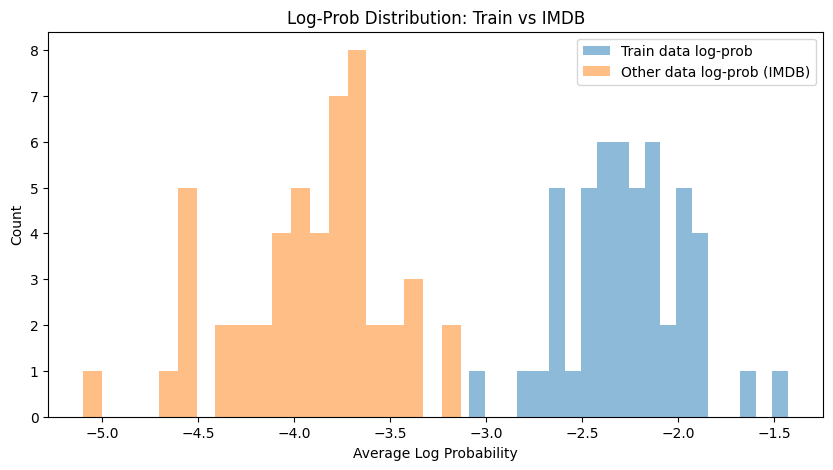

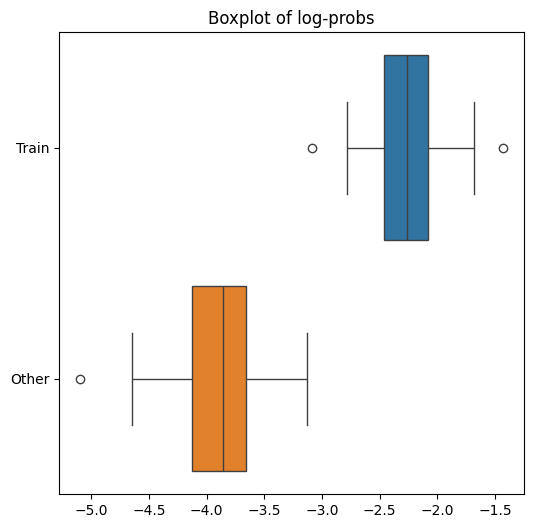

Train data average log-prob: -2.2618
Other data average log-prob: -3.9141
The average log-likelihood of the model for the training set data is higher => the training data is more consistent with the model distribution


In [47]:

plt.figure(figsize=(10,5))
plt.hist(train_log_probs, bins=20, alpha=0.5, label="Train data log-prob")
plt.hist(other_log_probs, bins=20, alpha=0.5, label="Other data log-prob (IMDB)")
plt.legend()
plt.title("Log-Prob Distribution: Train vs IMDB")
plt.xlabel("Average Log Probability")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,6))
sns.boxplot(data=[train_log_probs, other_log_probs], orient="h")
plt.yticks([0,1], ["Train", "Other"])
plt.title("Boxplot of log-probs")
plt.show()

avg_train = train_log_probs.mean()
avg_other = other_log_probs.mean()
print(f"Train data average log-prob: {avg_train:.4f}")
print(f"Other data average log-prob: {avg_other:.4f}")
if avg_train > avg_other:
    print("The average log-likelihood of the model for the training set data is higher => the training data is more consistent with the model distribution")
else:
    print("The model is more or similar to external data => the model is not particularly biased towards the training set")

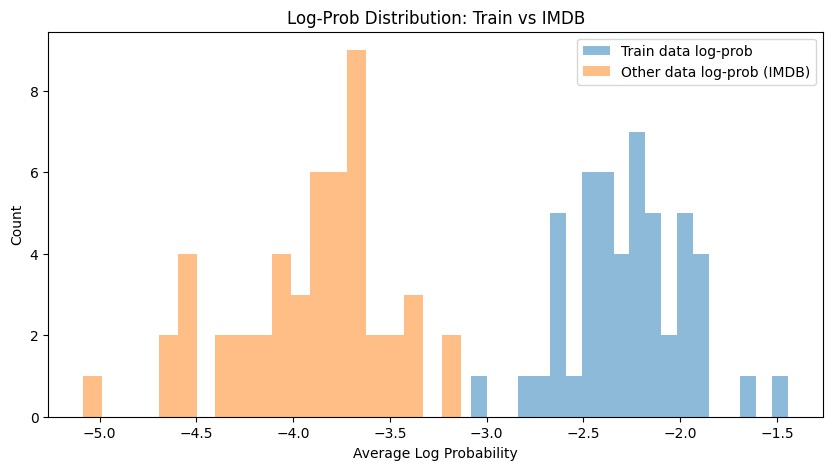

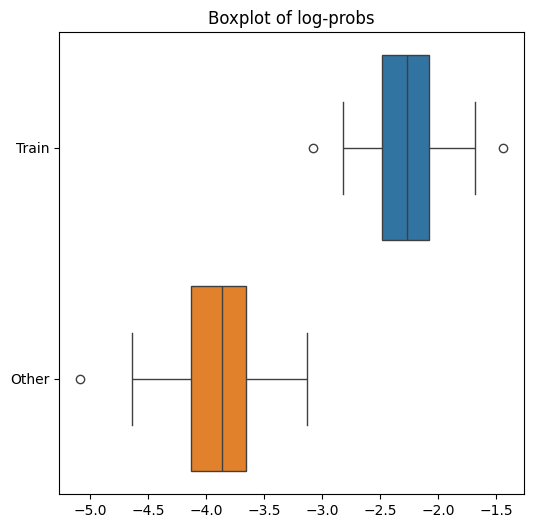

Train data average log-prob: -2.2668
Other data average log-prob: -3.9097
The average log-likelihood of the model for the training set data is higher => the training data is more consistent with the model distribution


In [48]:

model_to_analyze = PPO_REPO_NAME

model = AutoModelForCausalLM.from_pretrained(model_to_analyze).to(device)
model.eval()
tokenizer = AutoTokenizer.from_pretrained(model_to_analyze)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

def compute_log_prob(text: str) -> float:
    inputs = tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(**inputs).logits

    log_probs = torch.log_softmax(logits[:, :-1, :], dim=-1)
    labels = inputs.input_ids[:, 1:].unsqueeze(-1)  # shape: [batch_size, seq_len-1, 1]
    token_log_probs = torch.gather(log_probs, -1, labels).squeeze(-1)

    seq_log_prob = token_log_probs.mean(dim=1)  # shape: [batch_size]
    return seq_log_prob.item()

train_data = load_dataset(DATASET_ID, split="train")
train_data_sample = train_data.select(range(50))

other_data_all = load_dataset("imdb", split="test")
other_data_sample = other_data_all.select(range(50))


train_log_probs = []
for ex in train_data_sample:
    text = ex["prompt"] + " " + ex["chosen"]
    lp = compute_log_prob(text)
    train_log_probs.append(lp)

other_log_probs = []
for ex in other_data_sample:
    text = ex["text"]
    lp = compute_log_prob(text)
    other_log_probs.append(lp)

train_log_probs = np.array(train_log_probs)
other_log_probs = np.array(other_log_probs)

plt.figure(figsize=(10,5))
plt.hist(train_log_probs, bins=20, alpha=0.5, label="Train data log-prob")
plt.hist(other_log_probs, bins=20, alpha=0.5, label="Other data log-prob (IMDB)")
plt.legend()
plt.title("Log-Prob Distribution: Train vs IMDB")
plt.xlabel("Average Log Probability")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,6))
sns.boxplot(data=[train_log_probs, other_log_probs], orient="h")
plt.yticks([0,1], ["Train", "Other"])
plt.title("Boxplot of log-probs")
plt.show()


avg_train = train_log_probs.mean()
avg_other = other_log_probs.mean()
print(f"Train data average log-prob: {avg_train:.4f}")
print(f"Other data average log-prob: {avg_other:.4f}")
if avg_train > avg_other:
    print("The average log-likelihood of the model for the training set data is higher => the training data is more consistent with the model distribution")
else:
    print("The model is more or similar to external data => the model is not particularly biased towards the training set")

# Дополнительные баллы

Вы также можно заработать дополнительные баллы:
- Оформить репозитории на 🤗 (можно сделать коллекцию, так как у нас 3 репозитория): карточка модели с описанием задания, репортом качества и примерами генерации **[2 балла]**

# Специальный раздел для проверяющего

In [49]:
device = torch.device("cuda")

DPO_REPO_NAME = f"{REPO_NAME}-dpo"
PPO_REPO_NAME = f"{REPO_NAME}-ppo"
REWARD_MODEL_REPO_NAME = f"{REPO_NAME}-reward-model"

tokenizer = AutoTokenizer.from_pretrained(DPO_REPO_NAME)
check_model = AutoModelForCausalLM.from_pretrained(DPO_REPO_NAME)
check_model = check_model.to(device)
check_model = check_model.eval()

In [51]:
messages = [{"role": "user", "content": "What's your morning routine like?"}]

text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
model_inputs = tokenizer([text], return_tensors="pt").to(device)

generated_ids = check_model.generate(model_inputs.input_ids, max_new_tokens=256, do_sample=False)
response = tokenizer.decode(generated_ids, skip_special_tokens=True)[0]

TypeError: argument 'ids': 'list' object cannot be interpreted as an integer